In [5]:
import os
import kagglehub

# Assure-toi que ton token Kaggle est bien configuré si ce n'est pas déjà fait :
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_281b1a89e087f070531afb856fc923d6'  # ← ton token

path = kagglehub.competition_download('facial-keypoints-detection')
print("Dossier des fichiers :", path)
print("Contenu du dossier :", os.listdir(path))


100%|██████████| 76.3M/76.3M [00:00<00:00, 96.3MB/s]

Extracting files...


Dossier des fichiers : /root/.cache/kagglehub/competitions/facial-keypoints-detection
Contenu du dossier : ['test.zip', 'training.zip', 'SampleSubmission.csv', 'IdLookupTable.csv']


In [6]:
import zipfile

# Chemins vers les fichiers zip
training_zip_path = os.path.join(path, 'training.zip')
test_zip_path = os.path.join(path, 'test.zip')

# Extraction de training.zip
if os.path.exists(training_zip_path):
    with zipfile.ZipFile(training_zip_path, 'r') as zip_ref:
        zip_ref.extractall(path)
        print("training.csv extrait avec succès !")

# Extraction de test.zip
if os.path.exists(test_zip_path):
    with zipfile.ZipFile(test_zip_path, 'r') as zip_ref:
        zip_ref.extractall(path)
        print("test.csv extrait avec succès !")


training.csv extrait avec succès !
test.csv extrait avec succès !


In [7]:
import pandas as pd
import torch

def load_facial_data_torch(csv_path, is_test=False, device='cpu'):
    # On utilise quand même pandas pour lire le CSV (car PyTorch ne lit pas le CSV nativement)
    df = pd.read_csv(csv_path)
    
    # 1. Parser la colonne 'Image' directement en tenseur PyTorch
    # On sépare les chaînes par des espaces, convertit en float et on en fait un tenseur
    pixel_lists = [list(map(float, img_str.split())) for img_str in df['Image']]
    
    # Conversion en tenseur PyTorch et normalisation [0, 1]
    # Pour un CNN (réseau de neurones convolutif), on veut le format : (Batch, Canaux, Hauteur, Largeur)
    # On ajoute donc 1 canal pour le niveau de gris : (N, 1, 96, 96)
    images_t = torch.tensor(pixel_lists, dtype=torch.float32, device=device) / 255.0
    images_t = images_t.view(-1, 1, 96, 96)
    
    if is_test:
        return images_t, df
    
    # 2. Extraire et gérer les points clés (les cibles)
    # ⚠️ ATTENTION : PyTorch déteste les NaN (valeurs manquantes). Si tu entraînes ton modèle avec 
    # des NaN, tes gradients et ta Loss vont immédiatement devenir NaN.
    
    df_keypoints = df.drop(columns=['Image'])
    
    # Option A : Remplacer les NaN par la moyenne de la colonne (imputation simple)
    df_keypoints = df_keypoints.fillna(df_keypoints.mean())
    
    # Conversion en tenseur PyTorch
    keypoints_t = torch.tensor(df_keypoints.values, dtype=torch.float32, device=device)
    
    return images_t, keypoints_t, df

# --- Exemple d'utilisation ---
# Si tu as un GPU disponible :
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_images, train_keypoints, train_df = load_facial_data_torch(
    os.path.join(path, 'training.csv'), 
    device=device
)

print("Type images :", type(train_images), "| Taille :", train_images.shape)
print("Type points :", type(train_keypoints), "| Taille :", train_keypoints.shape)


Type images : <class 'torch.Tensor'> | Taille : torch.Size([7049, 1, 96, 96])
Type points : <class 'torch.Tensor'> | Taille : torch.Size([7049, 30])


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FacialKeypointsCNN(nn.Module):
    def __init__(self):
        super(FacialKeypointsCNN, self).__init__()
        
        # Bloc 1 : 96x96 -> 48x48
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        # Bloc 2 : 48x48 -> 24x24
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Bloc 3 : 24x24 -> 12x12
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # Bloc 4 : 12x12 -> 6x6
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        
        # Max Pooling
        self.pool = nn.MaxPool2d(2, 2)
        
        # Couches fully connected (linéaires)
        # 256 filtres * 6px * 6px = 9216 entrées
        self.fc1 = nn.Linear(256 * 6 * 6, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 30) # 30 sorties (15 points clés * 2 coordonnées x, y)
        
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        # Convolutions + Batch Norm + ReLU + Pooling
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        
        # Aplatir (Flatten)
        x = x.view(-1, 256 * 6 * 6)
        
        # Fully Connected avec Dropout pour éviter le surapprentissage (overfitting)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        
        # Pas d'activation à la fin car on fait de la régression linéaire (coordonnées)
        x = self.fc3(x)
        return x



In [9]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# 1. Normalisation des cibles (keypoints) entre -1 et 1
# On soustrait 48 (le centre de l'image) et on divise par 48
train_keypoints_normalized = (train_keypoints - 48.0) / 48.0

# 2. Split Entraînement / Validation (80% / 20%)
X_train, X_val, y_train, y_val = train_test_split(
    train_images.cpu().numpy(), 
    train_keypoints_normalized.cpu().numpy(), 
    test_size=0.2, 
    random_state=42
)

# 3. Conversion en tenseurs PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

# 4. Création des DataLoaders
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print(f"Batches d'entraînement : {len(train_loader)}")
print(f"Batches de validation : {len(val_loader)}")


Batches d'entraînement : 89
Batches de validation : 23


In [15]:
import copy

# Forcer l'utilisation du CPU
device = torch.device('cpu')
model = FacialKeypointsCNN().to(device)

criterion = nn.MSELoss()
# On augmente légèrement le Learning Rate à 0.002 pour apprendre plus vite
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)

epochs = 10  # Réduit à 10 époques pour aller très vite
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())

print("Début de l'entraînement ultra-rapide sur CPU...")

for epoch in range(epochs):
    # ==== ENTRAÎNEMENT ====
    model.train()
    running_loss = 0.0
    for images_b, keypoints_b in train_loader:
        # Tout reste sur le CPU
        images_b, keypoints_b = images_b.to(device), keypoints_b.to(device)
        
        optimizer.zero_grad()
        outputs = model(images_b)
        loss = criterion(outputs, keypoints_b)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images_b.size(0)
        
    epoch_loss = running_loss / len(train_loader.dataset)
    
    # ==== VALIDATION ====
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images_b, keypoints_b in val_loader:
            images_b, keypoints_b = images_b.to(device), keypoints_b.to(device)
            outputs = model(images_b)
            loss = criterion(outputs, keypoints_b)
            val_loss += loss.item() * images_b.size(0)
            
    epoch_val_loss = val_loss / len(val_loader.dataset)
    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        
    print(f"Epoch {epoch+1:2d}/{epochs} | Train Loss (MSE): {epoch_loss:.5f} | Val Loss (MSE): {epoch_val_loss:.5f}")

# Charger le meilleur modèle
model.load_state_dict(best_model_wts)
print(f"\n✅ Entraînement express sur CPU fini ! Meilleure Loss de Validation (MSE): {best_val_loss:.5f}")


Début de l'entraînement ultra-rapide sur CPU...
Epoch  1/10 | Train Loss (MSE): 0.42144 | Val Loss (MSE): 0.00888
Epoch  2/10 | Train Loss (MSE): 0.02713 | Val Loss (MSE): 0.01177
Epoch  3/10 | Train Loss (MSE): 0.02247 | Val Loss (MSE): 0.00866
Epoch  4/10 | Train Loss (MSE): 0.01924 | Val Loss (MSE): 0.00673
Epoch  5/10 | Train Loss (MSE): 0.01615 | Val Loss (MSE): 0.00627
Epoch  6/10 | Train Loss (MSE): 0.01297 | Val Loss (MSE): 0.00443
Epoch  7/10 | Train Loss (MSE): 0.01098 | Val Loss (MSE): 0.00421
Epoch  8/10 | Train Loss (MSE): 0.00891 | Val Loss (MSE): 0.00359
Epoch  9/10 | Train Loss (MSE): 0.00728 | Val Loss (MSE): 0.00452
Epoch 10/10 | Train Loss (MSE): 0.00624 | Val Loss (MSE): 0.00377

✅ Entraînement express sur CPU fini ! Meilleure Loss de Validation (MSE): 0.00359


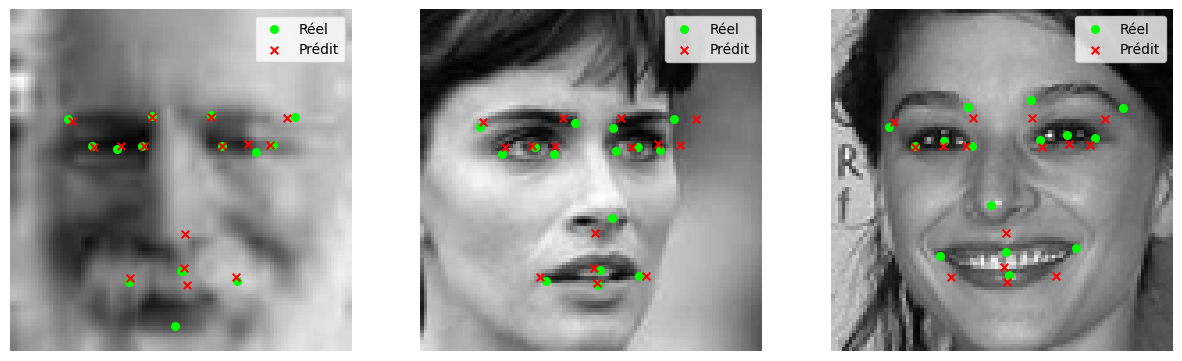

In [16]:
import matplotlib.pyplot as plt

# Prendre un échantillon de validation
model.eval()
with torch.no_grad():
    sample_img, sample_target = next(iter(val_loader))
    sample_img = sample_img.to(device)
    
    # Faire la prédiction
    pred = model(sample_img).cpu().numpy()
    
    # Denormaliser les prédictions et les vraies cibles
    pred_real = (pred * 48.0) + 48.0
    target_real = (sample_target.numpy() * 48.0) + 48.0
    img_numpy = sample_img.cpu().numpy()

# Afficher les 3 premières images avec les points clés réels (en vert) et prédits (en rouge)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    ax = axes[i]
    ax.imshow(img_numpy[i][0], cmap='gray')
    
    # Vrais points en vert
    ax.scatter(target_real[i][0::2], target_real[i][1::2], color='lime', marker='o', s=30, label='Réel')
    # Prédictions en rouge
    ax.scatter(pred_real[i][0::2], pred_real[i][1::2], color='red', marker='x', s=30, label='Prédit')
    ax.legend()
    ax.axis('off')
plt.show()


In [17]:
import os
import pandas as pd
import torch

# ==========================================
# 1. PRÉDIRE LES POINTS CLÉS SUR LE TEST SET
# ==========================================
model.eval()
with torch.no_grad():
    # S'assurer que le tenseur de test est bien sur le bon appareil (CPU/GPU)
    test_images_t = test_images.to(device)
    
    # Faire les prédictions
    test_predictions = model(test_images_t).cpu().numpy()
    
    # Dénormaliser les prédictions pour retrouver les pixels réels [0, 96]
    test_predictions_real = (test_predictions * 48.0) + 48.0

print(f"Prédictions générées : {test_predictions_real.shape}") # Devrait être (1783, 30)

# ==========================================
# 2. ASSOCIER LES PRÉDICTIONS AU LOOKUP TABLE
# ==========================================
# Récupérer la liste ordonnée des 30 noms de caractéristiques (les colonnes de train_df)
feature_names = list(train_df.drop(columns=['Image']).columns)

# Créer un dictionnaire de correspondance rapide : (ImageId, FeatureName) -> Coordonnée Prédite
preds_dict = {}
for i in range(len(test_predictions_real)):
    image_id = i + 1  # Kaggle utilise un index commençant à 1 pour les images de test
    for j, feat_name in enumerate(feature_names):
        preds_dict[(image_id, feat_name)] = test_predictions_real[i, j]

# Charger le fichier IdLookupTable.csv
lookup_table_path = os.path.join(path, 'IdLookupTable.csv')
lookup_df = pd.read_csv(lookup_table_path)

# Remplir la colonne 'Location' en utilisant notre dictionnaire de prédictions
lookup_df['Location'] = lookup_df.apply(
    lambda row: preds_dict[(row['ImageId'], row['FeatureName'])], 
    axis=1
)

# ==========================================
# 3. CRÉER LE FICHIER DE SOUMISSION KAGGLE
# ==========================================
# Pour la soumission, Kaggle demande uniquement les colonnes 'RowId' et 'Location'
submission_df = lookup_df[['RowId', 'Location']]

# Sécurité : S'assurer que les coordonnées ne sortent pas de l'image (entre 0 et 96)
submission_df['Location'] = submission_df['Location'].clip(0, 96)

# Sauvegarder en CSV (index=False est obligatoire pour éviter une colonne fantôme !)
submission_df.to_csv('submission_facial.csv', index=False)

print("\n🎉 Fichier de soumission créé avec succès : 'submission_facial.csv' !")
print(submission_df.head())


NameError: name 'test_images' is not defined